# Transformers

This notebook covers everything that is necessary to implement a Transformer model with causal self-attention, which is used for the majority of LLMs. The overall structure of the code is very similar to what you can find for open source (reference) implementations for models such as Mistral or Llama. Furthermore, parts of the interface is intentionally kept close to HuggingFace's `transformers` library, which is the go-to library for any Transformer based models. If you'd like to use pre-trained models, you should almost certainly look at [HuggingFace 🤗](https://huggingface.co/) first.

The model itself is implemented from scratch in pure PyTorch with a walk through the whole architecture and all its components. However for other parts, such as the tokeniser, existing implementations are used.

The model will be applied to the task of code completion, where you have a code snippet and want to generate the missing parts. For the dataset, it uses Python code that was gathered from GitHub repositories, therefore the model will only complete Python code. This will be pretty much exactly like code models, such as GitHub's copilot, with the exception that the model is much smaller and severely undertrained in comparison to these established/commercial models.

This notebook is quite long and is best viewed in Jupyter Lab, which can show the *Table of Contents* on the side, so you can navigate quickly to the relevant sections.

**Important:** Without a good GPU, you won't be able to train this model. The configuration used here (particularly the batch size) was chosen for a GPU with 24GB VRAM. And the dataset is larger than what you have used before, so it would take a very long time on weaker GPUs.

It is also worth noting, that while the training looks like the model would not really improve after 2-3 epochs, it is crucial to let it train for longer, as it can be observed, that the model fails to predict the end of sequence token within the first epochs, so it would always reach the maximum possible tokens during inference. It is also a known property of these Transformer models, that continuing the training is still beneficial, even though the accuracy might not improve. As you'll see during the inference section, the output is still not amazing, but now it at least resembles something reasonable (this was not the case with a model only trained for 10 epochs). There is still a repetition issue for the model, so that means it should be trained for longer.

In [1]:
# Only run this if you want to install the dependencies from the notebook
%pip install torch datasets safetensors transformers

In [2]:
from __future__ import annotations

import json
import math
import os
from dataclasses import dataclass, field
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import safetensors
import safetensors.torch
import torch
import torch.cuda.amp as amp
import torch.multiprocessing as mp
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datasets import load_dataset
from transformers import AutoTokenizer, PreTrainedTokenizer
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

# Jupyter notebook specific utils to render code blocks as markdown.
from IPython.display import HTML, Markdown, display

os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [3]:
MAX_LENGTH = 128
BATCH_SIZE = 280
NUM_EPOCHS = 30
LR = 1e-3

HIDDEN_SIZE = 256
# Number of Transformer layers
NUM_LAYERS = 4
# Number of attention heads
NUM_HEADS = 8

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

## GitHub Python Dataset

The dataset is available on HuggingFace: https://huggingface.co/datasets/thomwolf/github-python

It is only 500MB in size, but contains 285k samples of Python files from GitHub.

In [4]:
# Load the dataset from HuggingFace: https://huggingface.co/datasets/thomwolf/github-python
# Note: There is no split available, so all the data is under "train".
dataset = load_dataset("thomwolf/github-python", split="train")
dataset

Dataset({
    features: ['repo_name', 'ref', 'path', 'copies', 'content'],
    num_rows: 285264
})

### Filtering

Some of the files don't have any content (empty files). These don't add any value for the generative training, and dealing with `None`s during the data processing can become cumbersome. Hence, all empty files are dropped entirely.

In [5]:
num_before = dataset.num_rows

# Only keep samples that have actual text in the "content"
dataset = dataset.filter(lambda d: d["content"] is not None and d["content"].strip() != "")

print(f"Removed {num_before - dataset.num_rows} empty files")
dataset

Removed 19101 empty files


Dataset({
    features: ['repo_name', 'ref', 'path', 'copies', 'content'],
    num_rows: 266163
})

### Sample

Look at a sample, to see what is in the dataset.

`content` is the intersting field, that contains the actual code (content of the file). The code can be rendered with syntax highlighting by creating a markdown code block and displaying it in the Jupyter Notebook.

In [6]:
sample = dataset[1234]
sample

{'repo_name': 'bdrung/audacity',
 'ref': 'refs/heads/master',
 'path': 'lib-src/lv2/lv2/plugins/eg-metro.lv2/waflib/Tools/fc_scan.py',
 'copies': '183',
 'content': '#! /usr/bin/env python\n# encoding: utf-8\n# WARNING! Do not edit! http://waf.googlecode.com/git/docs/wafbook/single.html#_obtaining_the_waf_file\n\nimport re\nfrom waflib import Utils,Task,TaskGen,Logs\nfrom waflib.TaskGen import feature,before_method,after_method,extension\nfrom waflib.Configure import conf\nINC_REGEX="""(?:^|[\'">]\\s*;)\\s*(?:|#\\s*)INCLUDE\\s+(?:\\w+_)?[<"\'](.+?)(?=["\'>])"""\nUSE_REGEX="""(?:^|;)\\s*USE(?:\\s+|(?:(?:\\s*,\\s*(?:NON_)?INTRINSIC)?\\s*::))\\s*(\\w+)"""\nMOD_REGEX="""(?:^|;)\\s*MODULE(?!\\s*PROCEDURE)(?:\\s+|(?:(?:\\s*,\\s*(?:NON_)?INTRINSIC)?\\s*::))\\s*(\\w+)"""\nre_inc=re.compile(INC_REGEX,re.I)\nre_use=re.compile(USE_REGEX,re.I)\nre_mod=re.compile(MOD_REGEX,re.I)\nclass fortran_parser(object):\n\tdef __init__(self,incpaths):\n\t\tself.seen=[]\n\t\tself.nodes=[]\n\t\tself.names=[]\n\

In [7]:
# Render the code in a Markdown code block.
def render_code_block(text: str, lang: str = "python"):
    code_block = f"```{lang}\n{text}\n```"
    display(Markdown(code_block))

In [8]:
render_code_block(sample["content"])

```python
#! /usr/bin/env python
# encoding: utf-8
# WARNING! Do not edit! http://waf.googlecode.com/git/docs/wafbook/single.html#_obtaining_the_waf_file

import re
from waflib import Utils,Task,TaskGen,Logs
from waflib.TaskGen import feature,before_method,after_method,extension
from waflib.Configure import conf
INC_REGEX="""(?:^|['">]\s*;)\s*(?:|#\s*)INCLUDE\s+(?:\w+_)?[<"'](.+?)(?=["'>])"""
USE_REGEX="""(?:^|;)\s*USE(?:\s+|(?:(?:\s*,\s*(?:NON_)?INTRINSIC)?\s*::))\s*(\w+)"""
MOD_REGEX="""(?:^|;)\s*MODULE(?!\s*PROCEDURE)(?:\s+|(?:(?:\s*,\s*(?:NON_)?INTRINSIC)?\s*::))\s*(\w+)"""
re_inc=re.compile(INC_REGEX,re.I)
re_use=re.compile(USE_REGEX,re.I)
re_mod=re.compile(MOD_REGEX,re.I)
class fortran_parser(object):
	def __init__(self,incpaths):
		self.seen=[]
		self.nodes=[]
		self.names=[]
		self.incpaths=incpaths
	def find_deps(self,node):
		txt=node.read()
		incs=[]
		uses=[]
		mods=[]
		for line in txt.splitlines():
			m=re_inc.search(line)
			if m:
				incs.append(m.group(1))
			m=re_use.search(line)
			if m:
				uses.append(m.group(1))
			m=re_mod.search(line)
			if m:
				mods.append(m.group(1))
		return(incs,uses,mods)
	def start(self,node):
		self.waiting=[node]
		while self.waiting:
			nd=self.waiting.pop(0)
			self.iter(nd)
	def iter(self,node):
		path=node.abspath()
		incs,uses,mods=self.find_deps(node)
		for x in incs:
			if x in self.seen:
				continue
			self.seen.append(x)
			self.tryfind_header(x)
		for x in uses:
			name="USE@%s"%x
			if not name in self.names:
				self.names.append(name)
		for x in mods:
			name="MOD@%s"%x
			if not name in self.names:
				self.names.append(name)
	def tryfind_header(self,filename):
		found=None
		for n in self.incpaths:
			found=n.find_resource(filename)
			if found:
				self.nodes.append(found)
				self.waiting.append(found)
				break
		if not found:
			if not filename in self.names:
				self.names.append(filename)

```

### Statistics

In oder to get a better understanding of the data, we can look at some statistics. In this case, the number of characters, words and lines respectively.

In [9]:
# This cell may take a while to process everything, avoid running it, once you have looked at the statistics.

counts = dict(Chars=[], Words=[], Lines=[])

for d in tqdm(dataset):
    lines = d["content"].split("\n")
    counts["Lines"].append(len(lines))
    counts["Words"].append(sum([len(line.split(" ")) for line in lines]))
    counts["Chars"].append(sum([len(line) for line in lines]))

  0%|          | 0/266163 [00:00<?, ?it/s]

In [10]:
def show_stats(counts: dict[str, list[int]], bins: int = 100, num_stds: int = 1, separate_plots: bool = False):
    for key, value in counts.items():
        lengths = torch.tensor(value, dtype=torch.float)
        mean = torch.mean(lengths)
        std = torch.std(lengths)
        
        # Alignment is the maximum number of digits and two additional decimal points (+ the point itself).
        align = len(str(int(torch.max(lengths)))) + 3
        print(f"## {key}")
        print(f"    min:  {int(torch.min(lengths)):>{align}}")
        print(f"    max:  {int(torch.max(lengths)):>{align}}")
        print(f"    mean: {mean:>{align}.2f}")
        print(f"    std:  {std:>{align}.2f}")

        # Only plot the values up to `num_stds` standard deviations above the mean.
        # Otherwise, the plot is not really readable anymore.
        plt.hist(lengths[lengths < mean + num_stds * std], bins=bins, label=key)
        if separate_plots:
            plt.show()

    if not separate_plots:
        plt.legend()
        plt.show()

## Chars
    min:           1
    max:     1018911
    mean:    7684.15
    std:    21026.61
## Words
    min:          1
    max:     567461
    mean:   2110.55
    std:    5846.87
## Lines
    min:         1
    max:     47986
    mean:   209.39
    std:    486.07


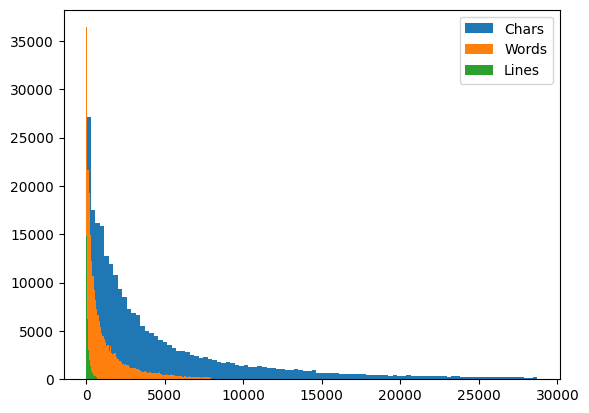

In [11]:
show_stats(counts)

### Train / Validation Split

Since there is no predefined split available, we simply split the data into 80% train, 10% validation and 10% test.

All of them use the method `dataset.train_test_split`, which might be a little confusing, but first an 80%/20% split is done, then the 20% are split again into two equal parts.

In [12]:
# Split the dataset into 80% train and 20% test/validation
dataset_split = dataset.train_test_split(train_size=0.8)
validation_test = dataset_split["test"].train_test_split(test_size=0.5)
dataset_split["validation"] = validation_test["train"]
dataset_split["test"] = validation_test["test"]
dataset_split

DatasetDict({
    train: Dataset({
        features: ['repo_name', 'ref', 'path', 'copies', 'content'],
        num_rows: 212930
    })
    test: Dataset({
        features: ['repo_name', 'ref', 'path', 'copies', 'content'],
        num_rows: 26617
    })
    validation: Dataset({
        features: ['repo_name', 'ref', 'path', 'copies', 'content'],
        num_rows: 26616
    })
})

## Tokenisation

The text needs to be converted to some form of numerical values, which is referred to as tokenisation. Using the raw bytes would of an UTF-8 encoded string, would be too large for the models. Similarly, using all characters of the alphabet, would result in large sequences, but at least the vocabulary is fairly small and it can represent every possible text with that alphabet. On the other end of the spectrum, each word would be a separate token, but since there are a plethora of words (even just in English), the vocabuarly size would be gigantic and it would always be limited to these exact words, so whenever a new word needs to be added, the model needs to be adapted and at least partially retrained.

The goal would be to get the compression of the word based tokenisation, while keeping the flexibility of the character based tokenisation. This is exactly what Byte Pair Encoding (BPE) was created for. BPE identifies the most commonly occurring n-grams (or subwords) and assign them a single token. Depending on the size of the vocabulary, there will be more elaborate n-grams (such as entire words), while also making sure that all words can still be created by combining multiple tokens.

BPE is *"trained"* (once) on a large amount of text, to make sure that as many words can be included in the process of creating the vocabulary and that they are representative of what n-grams occur most often. The general *"training"* algorithm goes as follows:

1. Start with all unique 1-grams (characters) as *initial tokens*.
2. Combine the most frequently occurring pairs of adjacent tokens into one.
3. Repeat until the desired vocabulary size is reached.

*Note: The data to create the tokeniser, does not need to be the same as the training data for the model.*

We will not implemented the tokeniser itself, but if you are interested in an educational implementation, you can have a look at https://github.com/karpathy/minbpe or https://huggingface.co/learn/nlp-course/en/chapter6/5

### Subword Tokenisation

BPE itself is more of a compression algorithm and was not specifically made to encode text on a word level, but that has been adapted for language model, to essentially apply the BPE only for subword tokenisation. The main difference is, that tokens now either need to be concatenated (i.e. one token is a suffix) or start a new word. Therefore, a token needs to be marked as being a suffix or a new word. In the most common tokenisers used for LLMs this is encoded as follows:

- Tokens marked with the special unicode character ▁ (U+2581) are the beginning of a new word (▁ is not rendered, it's only to distinguish them visually)
- Every other token will be considered as a suffix.

Example:

- `▁end` means that a new word `end` is started (i.e. you would add a space before writing this).
- `end` hoewever is a suffix, so it is concatenated with the previous token(s)
- `["▁end", "end", "▁end", "▁pret", "end"]` => `"endend end pretend"`

This allows to encode multiple words with the ending *"-end"* (or something like *"ing"* is very common in English), while also starting a word with *"end"*. The major drawback is, that there need to be two tokens for each subword that can either be at the beginning or in the middle/end of the word, but having two separate tokens for that, allows the model to also learn that they are fundamentally different in their use.

*Instead of marking the start of the word, it is also possible to mark all suffixes (e.g. BERT did that with `##end`)*.

#### Tokeniser for Code

It would be desirable to represent words that occur most often as a single token (especially to reduce the sequence length of the encoded text). Hence, a tokeniser specialised for Python would almost certainly have a single token for every keyword (`return`, `import`, etc.), so if you trained a BPE tokeniser specifically for this Python dataset, you would most likely get a more efficient tokenisation. However, this is out of scope for this exercise and we will instead use an already existing tokeniser, that was created for code (as opposed to general language), but not necessarily only for Python.

We are going to use the tokeniser for Code Llama (available on HuggingFace: https://huggingface.co/codellama/CodeLlama-7b-hf).  
*We only use the tokeniser, not the model itself, even though it would be available in the same repo.*

In [13]:
tokeniser = AutoTokenizer.from_pretrained("codellama/CodeLlama-7b-hf")
# Set the padding token to <unk>, because it has no dedicated pad token.
tokeniser.pad_token = tokeniser.unk_token
tokeniser

CodeLlamaTokenizerFast(name_or_path='codellama/CodeLlama-7b-hf', vocab_size=32016, model_max_length=1000000000000000019884624838656, is_fast=True, padding_side='left', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '<unk>', 'pad_token': '<unk>', 'additional_special_tokens': ['▁<PRE>', '▁<MID>', '▁<SUF>', '▁<EOT>']}, clean_up_tokenization_spaces=False),  added_tokens_decoder={
	0: AddedToken("<unk>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("<s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("</s>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32007: AddedToken("▁<PRE>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32008: AddedToken("▁<SUF>", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	32009: AddedToken("▁<MID>", rstrip=False, lst

In [14]:
# The example from above was taken from this tokeniser.
tokeniser.tokenize("endend end pretend")

['▁end', 'end', '▁end', '▁pret', 'end']

In [15]:
# Now with the actual code.
tokeniser.tokenize(sample["content"])

['▁#',
 '!',
 '▁/',
 'usr',
 '/',
 'bin',
 '/',
 'env',
 '▁python',
 '<0x0A>',
 '#',
 '▁encoding',
 ':',
 '▁utf',
 '-',
 '8',
 '<0x0A>',
 '#',
 '▁W',
 'ARNING',
 '!',
 '▁Do',
 '▁not',
 '▁edit',
 '!',
 '▁http',
 '://',
 'w',
 'af',
 '.',
 'google',
 'code',
 '.',
 'com',
 '/',
 'git',
 '/',
 'docs',
 '/',
 'w',
 'af',
 'book',
 '/',
 'single',
 '.',
 'html',
 '#',
 '_',
 'ob',
 'tain',
 'ing',
 '_',
 'the',
 '_',
 'w',
 'af',
 '_',
 'file',
 '<0x0A>',
 '<0x0A>',
 'import',
 '▁re',
 '<0x0A>',
 'from',
 '▁w',
 'af',
 'lib',
 '▁import',
 '▁Util',
 's',
 ',',
 'Task',
 ',',
 'Task',
 'Gen',
 ',',
 'Log',
 's',
 '<0x0A>',
 'from',
 '▁w',
 'af',
 'lib',
 '.',
 'Task',
 'Gen',
 '▁import',
 '▁feature',
 ',',
 'before',
 '_',
 'method',
 ',',
 'after',
 '_',
 'method',
 ',',
 'extension',
 '<0x0A>',
 'from',
 '▁w',
 'af',
 'lib',
 '.',
 'Config',
 'ure',
 '▁import',
 '▁conf',
 '<0x0A>',
 'IN',
 'C',
 '_',
 'RE',
 'GE',
 'X',
 '=""',
 '"',
 '(?',
 ':',
 '^',
 '|',
 "['",
 '">',
 ']\\',
 's',
 '*'

### Visualisation of Tokens

An excellent interative visualisation is available on: https://tiktokenizer.vercel.app/

The following uses a very similar visualisation, but without the interactivity.

Each token is rendered with a different colour. As the vocabulary is usually very large (e.g. 32k in the case of Code Llama), it is not possible to render all of them with a unique colour. Even in a single sample, which can already have hundreds of different tokens, the difference in the colours would be very small. Hence, there are only a handful of colours used, which are cycled in the same order. They were chosen such that there is a clear contrast between tokens, making the boundaries between tokens much easier to spot.  
*Note: Due to the cycling of colours, the same token might be shown with different colours (particularly noticable for indentation).*

When `show_control_chars=True` (the default), tabs `\t` and newlines `\n` are rendered with the symbols `⇥` and `↪`, respectively. This is particularly helpful to see which tokens the newlines belong to. In many tokenisers, you'll see that newlines are primarily at the beginning of tokens, for example: `\n\nimport`.

In [16]:
COLOURS = [
    "#FEF08A",
    "#BFDBFE",
    "#FED7AA",
    "#D9F99D",
    "#DDD6FE",
    "#E4E4E7",
    "#FECACA",
    "#A7F3D0",
    "#A5F3FC",
    "#F5D0FE",
]

def visualise_tokens(tokens: list[str], show_control_chars: bool = True, token_colours: list[str] | None = None):
    """
    Visualise the tokens with a different background colour for each token.

    Note: The colours are cycled and the same token might be shown with different colours.

    Later, for the attention visualisation, a colour can be passed for each token.

    Args:
        tokens (list[str]): List of tokens (output of the tokeniser, must be strings, not the ids)
        show_control_chars (bool): Whether to show special characters for `\t` and `\n`. [Default: True]
        token_colours (list[str], optional): Colours for each token. If not specified, the random colours
            are used.
    """
    assert token_colours is None or len(tokens) == len(
        token_colours
    ), f"Must have one token colour (got {len(token_colours)}) for each token ({len(tokens)})"
    elements = []
    for i, token in enumerate(tokens):
        colour = COLOURS[i % len(COLOURS)] if token_colours is None else token_colours[i]

        # These are Llama specific replacements, other tokenisers may be different.
        # The special unicode character ▁ (U+2581) is used to indicate the beginning of a new word.
        # So instead of indicating when something is a suffix (ending of a word),
        # all tokens are concatenated as is, except when ▁ is seen,
        # which starts a new word (adds a space).
        #
        # \t and \n are given as their control sequences.
        token = token.replace("▁", " ")
        token = token.replace("<0x0A>", "\n")
        token = token.replace("<0x09>", "\t")
        token = escape(token)
        
        if show_control_chars:
            # Show control characters for tabs and newlines.
            token = token.replace("\t", "<span style='color: #0005'>⇥</span>\t")
            token = token.replace("\n", "<span style='color: #0005'>↪</span>\n")
        # Render newlines as <br> tags
        token = token.replace("\n", "<br>")
        elements.append(f"<span style='background: {colour}'>{token}</span>")
        
    html = HTML(f"<div style='white-space: pre; font-family: monospace; line-height: 1.2'>{''.join(elements)}</div>")
    display(html)

In [17]:
visualise_tokens(tokeniser.tokenize(sample["content"]))

### Fill in the Middle (FIM)

Generative text models (including Transformers) will predict the next possible token. This means that if you wanted to fill something in between two chunks of text, which is usually what is desired for code completion, you need to handle code that comes after the current token as well.

The paper [Efficient Training of Language Models to Fill in the Middle](https://arxiv.org/abs/2207.14255) introduced a solution for Transformer models that relies on a clever tokenisation trick, in order for the model to learn when it is filling in the middle part of a code block.

This is achieved by splitting the text into three parts: *prefix*, *suffix* and *middle*.

Consider the example line:

```py
for i, name in enumerate(names):
```

Assuming someone has the overall structure of the for loop definition, but is missing the names of the variables (`|` indicates the cursor if it were in an editor):

```py
for | in enumerate(names):
```

Based on the context before (it is a for loop) and after the cursor (enumerating the names), we can confidently say that we need to define two variables, one of them being the index and the other one with some name that resembles the overall list.

In that case, the three parts can be defined as follows:

<div style="white-space: pre; font-family: monospace; line-height: 1.2"><span style="background: #FEF08A">for </span><span style="background: #BFDBFE">i, names</span><span style="background: #FED7AA"> in enumerate(names):</span></div>

where

- **prefix:** <span style="white-space: pre; font-family: monospace; line-height: 1.2; background: #FEF08A">for </span>
- **middle:** <span style="white-space: pre; font-family: monospace; line-height: 1.2; background: #BFDBFE">i, names</span>
- **suffx:**  <span style="white-space: pre; font-family: monospace; line-height: 1.2; background: #FED7AA"> in enumerate(names):</span></div>


Since the prefix and suffix remain unchanged during the generation (only the middle is expanded), they can be reorder, such that the middle part comes last.

$$
text \rightarrow (prefix, middle, suffix) \rightarrow (prefix, suffix, middle)
$$

This is called the PSM order (prefix, suffix, middle). To communicate the order to the model, each of the three sections start with a special token, such as `<PRE>`, `<SUF>` and `<MID>`.

$$
\texttt{<PRE>} \circ prefix \circ \texttt{<SUF>} \circ suffix \circ \texttt{<MID>} \circ middle \hspace{4em} (PSM)
$$

Hence, the sequence would look like this:

<div style="white-space: pre; font-family: monospace; line-height: 1.2"><span style="background: #E4E4E7">&lt;PRE&gt;</span><span style="background: #FEF08A">for </span><span style="background: #E4E4E7">&lt;SUF&gt;</span><span style="background: #FED7AA"> in enumerate(names):</span><span style="background: #E4E4E7">&lt;MID&gt;</span><span style="background: #BFDBFE">i, names</span></div><br>

During inference, it means that the sequence can end with the `<MID>` token and the model will know, how to take the context into account.

<div style="white-space: pre; font-family: monospace; line-height: 1.2"><span style="background: #E4E4E7">&lt;PRE&gt;</span><span style="background: #FEF08A">for </span><span style="background: #E4E4E7">&lt;SUF&gt;</span><span style="background: #FED7AA"> in enumerate(names):</span><span style="background: #E4E4E7">&lt;MID&gt;</span></div>

## Data Loader

The data needs to be tokenised to be fed to the model. There are two common strategies:

- **Pretokenise**

    Ideally, the whole dataset would be tokenised beforehand and then saved to disk, so that during training there is no overhead for the tokenisation. This has some drawbacks, namely that it is tied to a specific tokeniser and if you want to try a different one, you have to redo the whole tokenisation. The same applies to changing datasets. A big advantage is that you can only load the tokens that you need and don't need to include the entire text. In general, this is the more efficient way for the data loading when training text based models, particularly with large datasets and longer train times.

- **On Demand**

    On the other hand, if the data is tokenised on demand, i.e. whenever the data is loaded, it is more flexible and only needs to tokenise the data that is actually used. The advantage of this method, is that the processing can be done in background workers, that tokenise the next batch (on CPU) while the GPUs are doing all the calculations. This maximises utilisation of CPU and GPU, while also having no delay (in the other method the whole dataset needs to be processed before the training can start). However, the drawbacks here are that the same texts will be tokenised multiple times (assuming more than one epoch), which is certainly a bit wasteful. Also, if the model is small, it might be possible that one training iteration through the model is faster than the tokenisation. In that case, the GPU would be idle until the batch is fully processed. This should *never* happen.


We will focus on the latter (on demand loading), because it's conceptually simpler in regards to the implementation.

### Maxmimum Sequence Length

Some of the files contain thousands of lines of codes, which would result in a large number of tokens. Due to memory limitations, a large file cannot be used as a single sequence for the model. Therefore, it is necessary to create chunks of data, which should be measured in number of tokens, since that determines the memory requirements for the model.

There are multiple ways to create chunks, but if we were to use the whole dataset we'd end up with over 400 million tokens (>200k files with a mean of about 2k tokens, hence $200k \cdot 2k = 400M$). Assuming a maximum sequence length of 128 (to have a somewhat efficient training), that would result in about 3.2M samples. Or put differently, 16 samples per file, as there are 2k tokens on average per file, so $\frac{2k}{128} = 16$. All of that assumes that the chunks are non-overlapping, which determines what context is available for each code snippet.

To keep it simple, and somewhat balanced in regards to the context, we'll select a random excerpt from each file with the size (number of tokens) of the maximum sequence length. This means, during one epoch, each file is used only once, and in the next epoch, a different excerpt is chosen from each file. While this may never include every single possible excerpt, it is more realistic to have a good variety of code snippets even in shorter trainings.

In [18]:
class CodeChunkDataset(Dataset):
    """
    A simple dataset wrapper, that tokenises the code on demand and only keeps a random chunk.

    Using Fill in the Middle (FIM) where the code chunk is partitioned into prefix, middle and suffix
    and given in PSM order (prefix, suffix, middle).

    For each chunk, a ratio between [0.0, 0.9] (max_fim_ratio) is used to determine how much of the input
    should be in the middle.
    """
    def __init__(self, data, tokeniser: PreTrainedTokenizer, max_length: int = 256, max_fim_ratio: float = 0.9):
        self.data = data
        self.tokeniser = tokeniser
        self.max_length = max_length
        self.max_fim_ratio = max_fim_ratio

    def prepare_fim_sequence(self, sequence: list[int]) -> list[int]:
        num_tokens = len(sequence)
        # Ratio of middle part that should be predicted.
        mid_ratio = torch.rand((1,)).item() * self.max_fim_ratio
        # Ratio between prefix and suffix.
        pre_suf_ratio = torch.rand((1,)).item()
        mid_length = math.floor(mid_ratio * num_tokens)
        pre_length = math.floor((num_tokens - mid_length) * pre_suf_ratio)

        prefix = sequence[:pre_length]
        middle = sequence[pre_length:pre_length + mid_length]
        suffix = sequence[pre_length + mid_length:]

        # The input always starts with a <bos> token (beginning of sequence)
        # Then it's in the order of <prefix>, <suffix>, <middle> (PSM)
        fim_sequence = [self.tokeniser.bos_token_id, self.tokeniser.prefix_id, *prefix, self.tokeniser.suffix_id, *suffix, self.tokeniser.middle_id, *middle]
        return fim_sequence

    def __len__(self) -> int:
        return len(self.data)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        sample = self.data[index]
        # Tokenise the full text, because the chunk is based on number of tokens,
        # which isn't known beforehand.
        # This is not optimal, but is good enough for now.
        token_ids = tokeniser.encode(sample["content"], add_special_tokens=False)

        # The actual length of the text is shorter by 4, since there are 4 special tokens
        # for fill-in-the-middle: <bos>, <pre>, <suf>, <mid>
        max_length = self.max_length - 4

        if len(token_ids) < max_length:
            # When it's smaller, just use the whole text.
            chunk = token_ids
        else:
            start = int(torch.randint(len(token_ids) - max_length + 1, size=(1,)))
            end = start + max_length
            chunk = token_ids[start:end]
        input_ids = torch.tensor(self.prepare_fim_sequence(chunk))

        # As this is a next-token prediction, for every token in the sequence,
        # the next one can be predicted, hence there are as many labels
        # as tokens, just shifted by one (the last token predicts the <eos> token).
        # Thanks to the masking in the attention of the Transformer,
        # they can all be used at the same, while having the same effect,
        # as if they were done one at a time.
        labels = torch.cat([input_ids[1:], torch.tensor([self.tokeniser.eos_token_id])])

        return dict(input_ids=input_ids, labels=labels)

# Decode the FIM in PSM order into a string.
def decode_fim(input_ids: torch.Tensor, tokeniser: PreTrainedTokenizer) -> str:
    # Will silently ignore any additional special tokens and only use the first ones.
    pos_pre = torch.nonzero(input_ids == tokeniser.prefix_id)[0, 0]
    pos_mid = torch.nonzero(input_ids == tokeniser.middle_id)[0, 0]
    pos_suf = torch.nonzero(input_ids == tokeniser.suffix_id)[0, 0]

    # The order in the sequence is prefix, suffix, middle (PSM)
    prefix = input_ids[pos_pre:pos_suf]
    suffix = input_ids[pos_suf: pos_mid]
    middle = input_ids[pos_mid:]

    out = tokeniser.decode(torch.cat([prefix, middle, suffix]), skip_special_tokens=True)
    return out

In [19]:
class PaddingCollator:
    """
    A data collator combines a list of samples into a batched tensor.

    This pads the tokenised inputs to the max length within the batch
    with the padding token that is defined in the tokeniser.

    The labels are padded with the ignore_index
    By default it's -100, which is the one used to ignore labels in the CrossEntropy loss,
    see https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html

    Additionally, it returns an attention mask, since the padded tokens should not
    be included in the attention calculations.

    For autoregressive (iterative) decoding/inference, it is recomended to set padding_side="left",
    which makes it much easier to add the new token to the end after each step.
    """
    def __init__(self, tokeniser: PreTrainedTokenizer, ignore_index: int = -100, padding_side: str = "right"):
        self.tokeniser = tokeniser
        self.ignore_index = ignore_index
        self.padding_side = padding_side

    def __call__(self, data: list[dict[str, torch.Tensor]]) -> dict[str, torch.Tensor]:
        lengths = [len(d["input_ids"]) for d in data]
        max_length = max(lengths)
        padding_sizes = [[max_length - length, 0] if self.padding_side == "left" else [0, max_length - length] for length in lengths]
        input_ids = torch.stack([F.pad(d["input_ids"], pad, value=self.tokeniser.pad_token_id) for d, pad in zip(data, padding_sizes)])
        labels = torch.stack([F.pad(d["labels"], pad, value=self.ignore_index) for d, pad in zip(data, padding_sizes)])
        return dict(
            input_ids=input_ids,
            labels=labels,
            attention_mask=input_ids != self.tokeniser.pad_token_id,
        )

In [20]:
train_dataset = CodeChunkDataset(dataset_split["train"], tokeniser, max_length=MAX_LENGTH)
validation_dataset = CodeChunkDataset(dataset_split["validation"], tokeniser, max_length=MAX_LENGTH)
test_dataset = CodeChunkDataset(dataset_split["test"], tokeniser, max_length=MAX_LENGTH)

# Use padding on the right for training and validation, but padding on the left for test,
# because the iterative decoding requires the new token to be appended, but if
# there is padding after the last real token, this would need to be done separately
# for each sample in batch, as the position of the last token might be different.
#
# To keep the training as efficient as possible, the validation does not use the
# iterative decoding, but the same strategy as the training.
# At the end, only the test set is evaluated with the iterative decoding.
train_dataloader = DataLoader(train_dataset, collate_fn=PaddingCollator(tokeniser, padding_side="right"), batch_size=BATCH_SIZE, shuffle=True, num_workers=mp.cpu_count(), pin_memory=torch.cuda.is_available())
validation_dataloader = DataLoader(validation_dataset, collate_fn=PaddingCollator(tokeniser, padding_side="right"), batch_size=BATCH_SIZE, shuffle=False, num_workers=mp.cpu_count(), pin_memory=torch.cuda.is_available())
test_dataloader = DataLoader(test_dataset, collate_fn=PaddingCollator(tokeniser, padding_side="left"), batch_size=BATCH_SIZE, shuffle=False, num_workers=mp.cpu_count(), pin_memory=torch.cuda.is_available())

### Data Loading Example

In [26]:
batch = next(iter(train_dataloader))
batch

{'input_ids': tensor([[    1, 32007,  6422,  ..., 21027, 29918,  2917],
         [    1, 32007,  1018,  ...,     0,     0,     0],
         [    1, 32007,  2396,  ...,   565,   525,  8698],
         ...,
         [    1, 32007,  1660,  ..., 29918,  3952,  6774],
         [    1, 32007,  6553,  ...,  3986,  1583, 29889],
         [    1, 32007, 27428,  ...,   373,   385,    13]]),
 'labels': tensor([[32007,  6422, 29903,  ..., 29918,  2917,     2],
         [32007,  1018, 29901,  ...,  -100,  -100,  -100],
         [32007,  2396,  5574,  ...,   525,  8698,     2],
         ...,
         [32007,  1660, 29899,  ...,  3952,  6774,     2],
         [32007,  6553,  6982,  ...,  1583, 29889,     2],
         [32007, 27428, 29889,  ...,   385,    13,     2]]),
 'attention_mask': tensor([[ True,  True,  True,  ...,  True,  True,  True],
         [ True,  True,  True,  ..., False, False, False],
         [ True,  True,  True,  ...,  True,  True,  True],
         ...,
         [ True,  True,  Tru

#### Text in PSM order

In [27]:
batch_sample = batch["input_ids"][0]

print(tokeniser.decode(batch_sample))

<s> <PRE>UpdateSinkRequest <SUF>_pb2'
  # @@protoc_insertion_point(class_scope:google.logging.v2.UpdateSinkRequest)
  ))
_sym_db.RegisterMessage(UpdateSinkRequest)

DeleteSinkRequest = _reflection.GeneratedProtocolMessageType('DeleteSinkRequest', (_message.Message, <MID>', (_message.Message,), dict(
  DESCRIPTOR = _UPDATESINKREQUEST,
  __module__ = 'google.cloud.proto.logging.v2.logging_config


#### Text restored to original order

In [28]:
print(decode_fim(batch_sample, tokeniser=tokeniser))

UpdateSinkRequest', (_message.Message,), dict(
  DESCRIPTOR = _UPDATESINKREQUEST,
  __module__ = 'google.cloud.proto.logging.v2.logging_config_pb2'
  # @@protoc_insertion_point(class_scope:google.logging.v2.UpdateSinkRequest)
  ))
_sym_db.RegisterMessage(UpdateSinkRequest)

DeleteSinkRequest = _reflection.GeneratedProtocolMessageType('DeleteSinkRequest', (_message.Message,


## Model

The implementation is very close to the architecture that current LLMs, such as Llama, use. There have been various modifications/improvements to the original Transformer architecture, that have been widely adopted.

Notable changes that will be included here:

- No bias in any Linear.
- Pre-Norm (i.e. normalisation layer before the Attention/FFN blocks instead of after).
- Root Mean Square Norm (RMSNorm) instead of LayerNorm.
- Rotary Positional Embedding (RoPE) for the positional encoding instead of the sinnusoidal embeddings.

Each component will be explained in more detail.

The architecture of the model that will be implemented is depicted in the figure below.

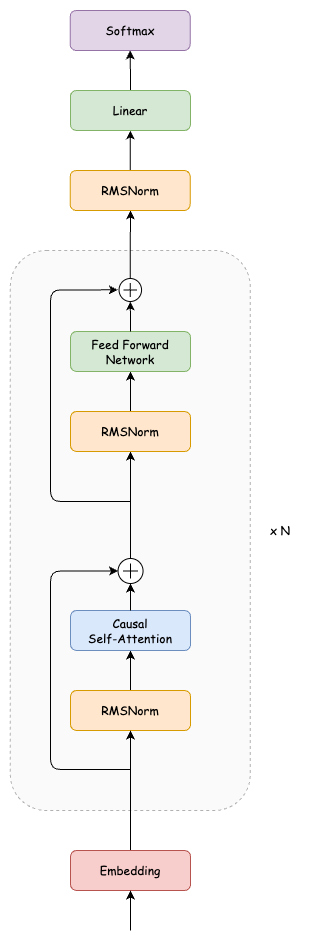

### Root Mean Square Normalisation (RMSNorm)

While [LayerNorm](https://pytorch.org/docs/stable/generated/torch.nn.LayerNorm.html) has been used in the original Transformer, most newer Transformer based models now use RMSNorm, which is very similar to LayerNorm, but slightly simpler.

LayerNorm has two properties:

- *re-centering*: Makes the model insensitive to shifts in the input/weights.
- *re-scaling*: Keeps the scale of the output intact.

The paper [Root Mean Square Layer Normalization](https://arxiv.org/abs/1910.07467) hypothesised that the *re-centering* of the inputs is dispensable, and only the *re-scaling* is necessary. With that in mind, a much simpler normalisation with the simple root means square statistics:

$$
RMS(a) = \sqrt{\frac{1}{N} \sum_{i=1}^{N}{a_{i}^{2}} }
$$

$$
RMSNorm(a_{i}) = \frac{a_{i}}{RMS(a)} W_{i}
$$

where $W$ is a learnable weight.

In [29]:
class RMSNorm(nn.Module):
    """
    Root Mean Square Norm

    A simplified LayerNorm that only uses the root mean square, i.e. keeps the
    re-scaling property but disposes of the re-centering.
    """

    def __init__(self, channels: int, eps: float = 1e-6):
        super().__init__()
        self.channels = channels
        self.eps = eps
        # Weight is initialised to 1.
        self.weight = nn.Parameter(torch.ones(channels))

    def extra_repr(self) -> str:
        return f"channels={self.channels}, eps={self.eps}"

    def _norm(self, input: torch.Tensor) -> torch.Tensor:
        # rsqrt is the reciprocal square root, i.e. 1/sqrt(x)
        # which is slightly faster than dividing by the sqrt.
        return input * torch.rsqrt(
            torch.mean(input**2, dim=-1, keepdim=True) + self.eps
        )

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        # The claculation for the Norm is forced to float32, because the
        # extra precision is needed, regardless of what the input format was.
        return self._norm(input.to(torch.float32)).type_as(input) * self.weight

### Attention

Attention is the heart of the Transformer. Specifically, Multi-Head Attention is employed, where the input is divided along the channel dimension (hidden size) and fed to $H$ different heads. Each head calculates the attention between the tokens with the following equation:

$$
Attention(Q, K, V) = softmax\left(\frac{QK^{T}}{\sqrt{d_{k}}}\right) V
$$

where

- $Q = x_{q}W_{q} \text{\small{(Query)}}$
- $K = x_{k}W_{k} \text{\small{(Key)}}$
- $V = x_{v}W_{v} \text{\small{(Value)}}$

and in self-attention: $x_{q} = x_{k} = x_{v}$, i.e. the query, key and value are derived from the same input, but all weights ($W_{q}, W_{k} \text{ and } W_{v}$) are independent of each other.

The Multi-Head Attention is shown in the figure below.

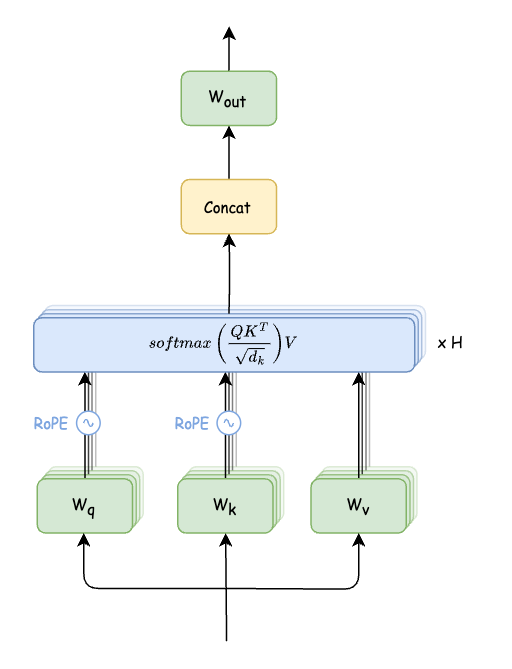

*Note: All weights $W$ can be implemented with `nn.Linear(in_channels, out_channels, bias=False)`, but since no biases are used, it boils down to only having the weights (hence they are not named Linear in the figure), but it is recommended to use Linear layers.*

### Rotary Positional Embedding (RoPE)

Rotary positional embeddings encode the positions by rotating the vectors based on their position in the sequence. This is the most common form of positional encodings in current Transformer models, including many LLMs. Because of some properties of the rotation, the dot product in the attention with the two rotated vectors will result in a relative rotation between the two.


Reminder, a rotation matrix in the Euclidean space is defined as: $
R = \begin{bmatrix}
    \cos \theta & -\sin \theta \\
    \sin \theta & \cos \theta \\
\end{bmatrix}
$, and multiplying this matrix with $[x, y]$ coordinates, will rotate them by the angle $\theta$.

$
Rv = \begin{bmatrix}
    \cos \theta & -\sin \theta \\
    \sin \theta & \cos \theta \\
\end{bmatrix}
\begin{bmatrix}
    x \\
    y \\
\end{bmatrix}
= \begin{bmatrix}
    x \cos \theta - y \sin \theta \\
    x \sin \theta + y \cos \theta \\
\end{bmatrix}
$

Since the input vectors have a much higher dimension than two, they cannot be multiplied directly, instead the dimension is divided into two sub-spaces, which represent x and y, respectively. Afterwards, each pair is rotated accordingly.

For example for a feature vector with dimension 6, there would be 3 different rotation matrices for a single feature vector. Then based on the position $m$ in the sequence, the roatation angle is multiplied by the position $m$. Thus, the rotation matrices at position $m$ are defined as follows:

$$
R_{m} = \begin{bmatrix}
    \cos m\theta_{1} & -\sin m\theta_{1} & 0 & 0 & 0 & 0 \\
    \sin m\theta_{1} & \cos m\theta_{1} & 0 & 0 & 0 & 0 \\
    0 & 0 & \cos m\theta_{2} & -\sin m\theta_{2} & 0 & 0 \\
    0 & 0 & \sin m\theta_{2} & \cos m\theta_{2} & 0 & 0 \\
    0 & 0 & 0 & 0 & \cos m\theta_{3} & -\sin m\theta_{3} \\
    0 & 0 & 0 & 0 & \sin m\theta_{3} & \cos m\theta_{3} \\
\end{bmatrix}
$$

Where $\theta_{i} = \frac{1}{10000^{\frac{2(i - 1)}{dim}}}$, i.e. one specific angle for each rotation matrix ($10000$ is the value that was chosen by the original paper).

For a more detailed explanation, see https://medium.com/@ngiengkianyew/understanding-rotary-positional-encoding-40635a4d078e

Or you can read the paper that introduced RoPE: [RoFormer: Enhanced Transformer with Rotary Position Embedding
](https://arxiv.org/abs/2104.09864)

*Note: You'll often see the equivalent formulation with complex numbers, but since not all hardware supports the complex calculations, the following implementation uses real numbered version.*

In [30]:
# Computes the real numbered frequencies (cos/sin) for the rotation matrices
def compute_freqs_cos_sin(
    dim: int, end: int, theta: float = 10000.0
) -> tuple[torch.Tensor, torch.Tensor]:
    freqs = 1.0 / (theta ** (torch.arange(0, dim, step=2, dtype=torch.float) / dim))
    freqs = torch.outer(torch.arange(end), freqs)
    freqs_cos = torch.cos(freqs)
    freqs_sin = torch.sin(freqs)
    return freqs_cos, freqs_sin


class RotaryEmbeddingReal(nn.Module):
    """
    Rotary Positional Embeddings (RoPE) calculated with real numbers.

    This is the equivalent calculation for the rotary embeddings but with real numbers
    instead of complex numbers, which is supported by all hardware configurations, but
    technically a little slower than the complex calculation if it is supported by the
    hardware.
    """

    freqs_cos: torch.Tensor
    freqs_sin: torch.Tensor

    def __init__(self, dim: int, max_length: int, theta: float = 10000.0):
        super().__init__()
        self.dim = dim
        self.max_length = max_length
        self.theta = theta
        # Dimension: max_length x dim
        freqs_cos, freqs_sin = compute_freqs_cos_sin(dim, max_length, theta=theta)
        self.register_buffer("freqs_cos", freqs_cos, persistent=False)
        self.register_buffer("freqs_sin", freqs_sin, persistent=False)

    def extra_repr(self) -> str:
        return f"dim={self.dim}, max_length={self.max_length}, theta={self.theta}"

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        """
        Args:
            input (torch.Tensor): Input to which the positional encoding is applied.
                The last two dimensions of the input must be seq_len and dim, while
                there can be any number of additional leading dimensions.
                [Dimension: * x seq_len x dim]

        Returns:
            out (torch.Tensor): Output with the positional encoding applied.
                [Dimension: * x seq_len x dim]
        """
        *sizes, seq_len, last = input.size()
        # Last dimension is halved as it is regarded as the tuple of 2 elements that was
        # flattened, e.g. [1, 2, 3, 4] -> [[1, 2], [3, 4]], where each tuple represents
        # a complex number, in this case it would be: 1 + 2i and 3 + 4i (or x,y-coordinates)
        input_real, input_imaginary = input.reshape(
            *sizes, seq_len, last // 2, 2
        ).unbind(-1)
        freqs_cos = self.freqs_cos[:seq_len]
        freqs_sin = self.freqs_sin[:seq_len]
        out_real = input_real * freqs_cos - input_imaginary * freqs_sin
        out_imaginary = input_real * freqs_sin + input_imaginary * freqs_cos
        # Combine the real and imaginary results and flatten the tuples again
        out = torch.stack([out_real, out_imaginary], dim=-1).flatten(-2)
        return out

### Causal Self-Attention

Causal Self-Attention restricts any token to only attend to preceeding tokens. This mimiks the autoregressive (iterative) decoding, where one token is predicted at a time only with the already available tokens.

For example (using words as tokens for simplicity):

- $t_1$: **This**
- $t_2$: This **is**
- $t_3$: This is **the**
- $t_4$: This is the **iterative**
- $t_5$: This is the iterative **decoding**
- $t_6$: This is the iterative decoding **process**
- $\dots$

You can observe a triangular structure from the decoding output. If your input has a length of 9 tokens, you only predict the $10^{th}$ based on the 9 existing tokens. In order to learn the whole sequence, each time step would need to be an input to the model. Doing that one at a time is very inefficient, but during training, each time step can be predicted at once, by simply restricting the attention for each token to the preceeding tokens.

Concretely, by using the full length sequence (e.g. the 9 tokens mentioned previously), not only the $10^{th}$ token can predicted based on the 9 preceeding ones, but for every token at time step $t$ a prediction can be made for the next token ($t + 1$) with only including its preceeding tokens in the attention.
This means that a single forward pass of the model with a sequence of $n$ tokens will not only have one prediction that contributes to the loss, but $n - 1$ predictions, making the training much more efficient.

To achieve this, the attention for all future tokens needs to be set to 0 (or masked). As with the example above, this means that only the part of the matrix below the diagonal will be considered (or conversely, the part above the diagonal is set to zero).

The desired attention matrix would look like this:

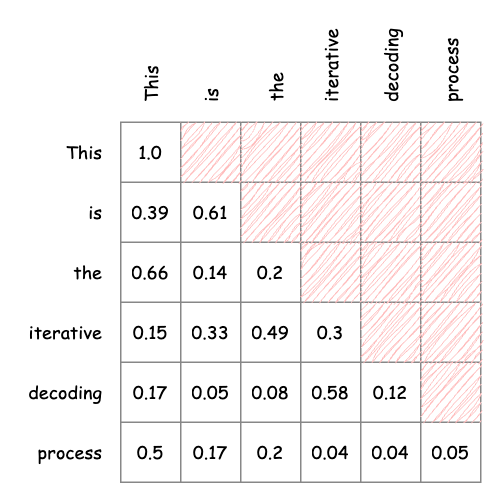


Note that the softmax is applied **without** the ignored tokens, i.e. the values still add up to 1, which means that the future tokens cannot just be set to 0 after applying the softmax, otherwise it would affect the probabilities of the actual tokens.

An easy way to achieve this, is by setting the future tokens to $-\infty$ (`float("-inf")` in Python) before the softmax, which will make them 0 while not affecting the rest, since $e^{-\infty} = 0$.

*Hint: Use [`torch.tril(x)`](https://pytorch.org/docs/stable/generated/torch.tril.html) to get the lower triangular part or [`torch.triu(x, diagonal=1)`](https://pytorch.org/docs/stable/generated/torch.triu.html) to get the upper triangular part (without the main diagonal).*

In practice, you should use [`F.scaled_dot_product_attention`](https://pytorch.org/docs/stable/generated/torch.nn.functional.scaled_dot_product_attention.html), PyTorch's implementation of the attention, which is much faster and uses less memory, as it implements FlashAttention-2.

In [31]:
class SelfAttention(nn.Module):
    """
    Self-Attention using the scaled_dot_product_attention and using
    Rotary Positional Embeddings (RoPE).
    """

    def __init__(
        self,
        input_size: int = 256,
        num_heads: int = 8,
        dropout_rate: float = 0.0,
        max_length: int = 256,
    ):
        super().__init__()
        self.input_size = input_size
        self.num_heads = num_heads
        # The feature generation is partitioned into the number of heads across the channels,
        # therefore, one head only produces a fraction of the feature vector.
        # Important: Each head receives the whole sequence (in regards to the time steps)
        # But only produces parts of the final feature vector.
        self.head_size = input_size // num_heads
        self.dropout_rate = dropout_rate
        self.max_length = max_length
        self.attn_hook = None

        # Each head produces the same fraction of the output, so each projection can be
        # done in a single linear then split up into the heads.
        self.proj_q = nn.Linear(input_size, self.num_heads * self.head_size, bias=False)
        self.proj_k = nn.Linear(input_size, self.num_heads * self.head_size, bias=False)
        self.proj_v = nn.Linear(input_size, self.num_heads * self.head_size, bias=False)
        self.proj_out = nn.Linear(self.num_heads * self.head_size, input_size, bias=False)
        self.rotary_embedding = RotaryEmbeddingReal(self.head_size, max_length=max_length)
        self.dropout = nn.Dropout(p=dropout_rate)

    # This is used for the attention visualisation, to capture
    # the attention weight without any modifications.
    def register_attention_hook(self, hook: "AttentionHook"):
        self.attn_hook = hook

    def forward(
        self,
        input: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            input (torch.Tensor): Input of the attention, which is used to
                calculate query, key and value.
                [Dimension: batch_size x seq_len x input_size]
            mask (torch.Tensor, optional): Attention mask to decide which tokens need to
                be attended to.
                It is expected to be a boolean mask where True indicates the
                token should be considered for the attention as a matrix between the
                query and key/value tokens, hence the last two dimensions need to be the
                seq_len of the query and the input respectively. As this is self-attention,
                both have the same seq_len.
                [Dimension: batch_size x seq_len x seq_len]
        """
        batch_size, seq_len, _ = input.size()

        q = self.proj_q(input)
        k = self.proj_k(input)
        v = self.proj_v(input)

        # Separate the combined projections into the individual heads.
        q = q.view(batch_size, seq_len, self.num_heads, self.head_size)
        k = k.view(batch_size, seq_len, self.num_heads, self.head_size)
        v = v.view(batch_size, seq_len, self.num_heads, self.head_size)

        # num_heads need to be placed as a batch dimension, since
        # the last two dimensions should be sequence length and embedding dimensions,
        # respectively for the matrix multiplication.
        # From: batch_size x seq_len x num_heads x head_size
        # To: batch_size x num_heads x seq_len x head_size
        q = q.transpose(1, 2)
        k = k.transpose(1, 2)
        v = v.transpose(1, 2)

        # Apply rotary positional encoding (RoPE)
        # only to query and key.
        q = self.rotary_embedding(q)
        k = self.rotary_embedding(k)

        # Attention calculation
        #
        # Note: You should never do that by hand, but use F.scaled_dot_product_attention
        # from PyTorch instead, as that is a much more optimised version, which is not only
        # much faster, but also uses less memory.
        # This is purely to show how it would be implemented (and to visualise the attention).
        #
        # QK^T / d_k
        attn_weight = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_size)
        # Only the lower diagonal (including the main diagonal) should be included in
        # the attention calculation, such that only preceeding tokens are considered.
        # i.e. the lower diagonal is set to True.
        attn_mask = torch.tril(torch.ones_like(attn_weight, dtype=torch.bool))
        # When an attention mask is given, make sure to only include them. This is
        # mostly for the padding, hence all padidng tokens will be False in this
        # attention mask.
        if mask is not None:
            # Mask needs an extra singular dimensions for the added num_heads dimension
            # in the inputs.
            # From: batch_size x seq_len x seq_len
            # To: batch_size x 1 x seq_len x seq_len
            attn_mask &= mask.unsqueeze(1)
        # Before the softmax, set all values that should not contribute to the attention
        # to -inf.
        # ~x is the bitwise negation of x (just a boolean negation in this case).
        attn_weight[~attn_mask] = float("-inf")
        # Some tokens might have no attention at all, which will get to NaN
        # after the softmax, so just set these to 0 to avoid NaNs.
        # They will be ignored anyway, so it doesn't matter what values they have.
        attn_weight[torch.all(torch.isinf(attn_weight), dim=-1)] = 0.0
        attn_weight = torch.softmax(attn_weight, dim=-1)
        attn_weight = self.dropout(attn_weight)

        # Save the attention for the visualisation.
        # Never done during training!
        if self.attn_hook is not None and not self.training:
            self.attn_hook.save(attn_weight)

        out = torch.matmul(attn_weight, v)

        # Combine the heads and get back to the input size
        # From: batch_size x num_heads x seq_len x head_size
        # To: batch_size x x seq_len x num_heads * head_size
        out = out.transpose(1, 2).reshape(batch_size, seq_len, -1)

        out = self.proj_out(out)
        out = self.dropout(out)

        return out

### Feed Forward Network (FFN)

The Feed Forward Network (FFN) is a simple MLP with two layers, where the input is usually projected to a larger hidden dimension and then back down to the original input size. Historically, an expansion factor of 4 was often applied (e.g. `input_size = 256` and `hidden_size = 1024`), but it has been reduced frequently in recent times. It is also perfectly acceptable not to apply any expansion and use `hidden_size = input_size`.

A crucial part of the FFN is the activation function (as during the attention there is no non-linearity). The original Transformer used [ReLU](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html), which was overtaken quickly by [Gaussian Error Linear Units (GeLU)](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html).
With the rise of LLMs, it was outperformed by Swish Gated Linear Unit (SwiGLU), which is a combination of [Swish aka SiLU (Sigmoid Linear Unit)](https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html) and the Gated Linear Unit (GLU) (not to be confused with GeLU), where Swish is applied to the gate instead of the sigmoid function.

$$
GLU(x) = \sigma(xW_{gate}) \otimes (xW_{in})
$$
$$
Swish(x) = x \odot \sigma(x)
$$
$$
SwiGLU(x) = Swish(xW_{gate}) \otimes (xW_{in})
$$

where $\odot$ denotes the element-wise multiplication (Hadamard product) and $\otimes$ the gating (which is also an element-wise multiplication, but as seen with the LSTMs, that is the more common notation). You might be wondering, what the difference between GLU and Swish is, since both have a sigmoid multiplied by the input. The primary difference between the two is, that Swish is just an activation function (no weights, sigmoid is applied to the same input), whereas GLU has one projection for the input transformation ($W_{in}$) and one for the gate ($W_{gate}$). Hence, Swish gates the input with itself and GLU has a separate learned gate.

SwiGLU has performed better in many experiments, but besides this empirical evidence, there is no theoretical reason why it is better. To quote from the paper [GLU Variants Improve Transformer](https://arxiv.org/abs/2002.05202), which introduced SwiGLU:

> We have extended the GLU family of layers and proposed their use in Transformer. In a transfer-learning
setup, the new variants seem to produce better perplexities for the de-noising objective used in pre-training,
as well as better results on many downstream language-understanding tasks. These architectures are simple
to implement, and have no apparent computational drawbacks. We offer no explanation as to why these
architectures seem to work; we attribute their success, as all else, to divine benevolence.

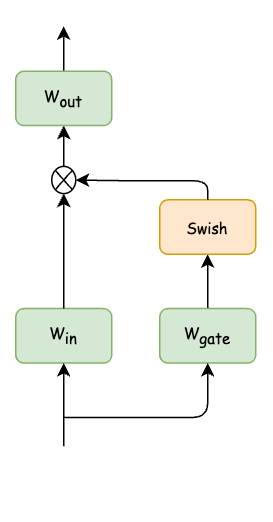


As described at the beginning of this section, the input of the Feed Forward Network is projected up to the `hidden_size` with $W_{in}$ and $W_{gate}$ and then back down with $W_{out}$:

- $W_{in} / W_{gate}: \text{input\_size} \rightarrow \text{hidden\_size}$
- $W_{out}: \text{hidden\_size} \rightarrow \text{input\_size}$


*Hint: You can use [`F.silu`](https://pytorch.org/docs/stable/generated/torch.nn.functional.silu.html), which is PyTorch's implementation of Swish.*

In [32]:
class FeedForward(nn.Module):
    """
    A feed forward module using SwiGLU (Swish Gated Linear Unit) as the activation
    function.
    """

    def __init__(self, input_size: int, hidden_size: int, dropout_rate: float = 0.0):
        super().__init__()
        self.proj_in = nn.Linear(input_size, hidden_size, bias=False)
        self.proj_gate = nn.Linear(input_size, hidden_size, bias=False)
        self.proj_out = nn.Linear(hidden_size, input_size, bias=False)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, input: torch.Tensor) -> torch.Tensor:
        out = F.silu(self.proj_gate(input)) * self.proj_in(input)
        out = self.proj_out(out)
        out = self.dropout(out)
        return out

### Transformer Block

Now we can put everything together to create the Transformer Block, which contains a Multi-Head Attention and a Feed Forward Network with an RMSNorm before each block, as depicted in the overall Model architecture (the grey block).

In [33]:
class TransformerBlock(nn.Module):
    """
    A Transformer block with a (Multi-Head)Attention block and a feed forward.

    Includes improvements that have been integrated recently, this is essentially what
    is used in models like LLaMa.

    Notable changes:
        - No bias in any Linear
        - Rotary Positional Embedding (RoPE)
        - Pre-Norm
        - Root Mean Square Norm (RMSNorm)
    """

    def __init__(
        self,
        input_size: int = 256,
        num_heads: int = 8,
        dropout_rate: float = 0.0,
        max_length: int = 256,
    ):
        super().__init__()
        self.input_size = input_size
        self.num_heads = num_heads
        # The input is divided evenly across the heads.
        # It is divided across the channel dimension, hence
        # all heads receive the full sequence, but only
        # a part of the features.
        self.head_size = input_size // num_heads
        self.dropout_rate = dropout_rate
        self.max_length = max_length

        self.attention = SelfAttention(
            input_size,
            num_heads=num_heads,
            dropout_rate=dropout_rate,
            max_length=max_length,
        )
        # For the FFN, an expansion ratio of 3 is used, hence hidden_size = 3 * input_size.
        self.feed_forward = FeedForward(input_size, hidden_size=3 * input_size)
        self.norm_attn = RMSNorm(input_size)
        self.norm_ff = RMSNorm(input_size)

    def forward(
        self,
        input: torch.Tensor,
        mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            input (torch.Tensor): Input of the attention, which is used to
                calculate query, key and value.
                [Dimension: batch_size x seq_len x input_size]
            mask (torch.Tensor, optional): Attention mask to decide which tokens need to
                be attended to.
                It is expected to be a boolean mask where True indicates the
                token should be considered for the attention as a matrix between the
                query and key/value tokens, hence the last two dimensions need to be the
                seq_len of the query and the input respectively. As this is self-attention,
                both have the same seq_len.
                [Dimension: batch_size x seq_len x seq_len]
        """
        out = input + self.attention(self.norm_attn(input), mask=mask)
        out = out + self.feed_forward(self.norm_ff(out))
        return out

### Full Transformer

Everything building block of the model is now available, they just need to be combined to the a full Transformer model. The model takes a sequence of tokens (one integer per token) as input, which in then embedded as a vector. Afterwards, it is passed through a series of Transformer blocks, and finally, the output of the last transformer block is then transformed to predict tokens based on the available vocabulary (a Linear layer with the size of the vocaublary as output).

**Important: Do not apply softmax in the model.** PyTorch's [CrossEntropyLoss](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) expects the raw logits, not the softmax normalised probabilities! The softmax is only needed later if you want to get the probabilities (or confidence scores) for each token, which may be skipped for greedy decoding where only the token with the highest value is chosen.

In [34]:
class Transformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        hidden_size: int = 256,
        num_layers: int = 4,
        num_heads: int = 8,
        dropout_rate: float = 0.2,
        max_length: int = 256,
    ):
        """
        Args:
            vocab_size (int): Size of the vocabulary.
            hidden_size (int): Hidden size for the intermediate layers [Default: 256]
            num_layers (int): Number of Transformer layers [Default: 4]
            num_heads (int): Number of attention heads [Default: 8]
            dropout_rate (float): Dropout probability [Default: 0.2]
            max_length (int): Maximum length for the transformer [Default: 256]
        """
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        self.max_length = max_length

        # An embedding for each token in the vocabulary.
        self.embedding = nn.Embedding(self.vocab_size, embedding_dim=self.hidden_size)

        self.layers = nn.ModuleList(
            [
                TransformerBlock(
                    input_size=self.hidden_size,
                    num_heads=self.num_heads,
                    dropout_rate=self.dropout_rate,
                    max_length=self.max_length,
                )
                for _ in range(self.num_layers)
            ]
        )

        # Head to project onto the vocabulary.
        self.lm_head = nn.Sequential(
            RMSNorm(self.hidden_size),
            nn.Linear(self.hidden_size, self.vocab_size, bias=False),
        )
        self.reset_parameters()

    def reset_parameters(self):
        self.apply(self._init_weights)
        # Based on GPT-2, initialise the weight of the layers whose output is added to
        # the residual with a factor 1/sqrt(N) where N is the number of residual layers.
        # In this case there are 2 residual layers per transformer block, one for the
        # attention and the other for the feed forward.
        for name, param in self.named_parameters():
            if name.endswith("proj_out.weight"):
                nn.init.normal_(
                    param, mean=0.0, std=0.02 / math.sqrt(2 * self.num_layers)
                )

    # Recommended initialisation of weights for Transformer models.
    # Not all of the layers are actually present in this model.
    def _init_weights(self, module: nn.Module):
        if isinstance(module, (nn.Linear, nn.Conv2d, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            bias = getattr(module, "bias", None)
            if bias is not None:
                nn.init.zeros_(bias)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def config(self) -> dict:
        return dict(
            vocab_size=self.vocab_size,
            hidden_size=self.hidden_size,
            num_layers=self.num_layers,
            num_heads=self.num_heads,
            dropout_rate=self.dropout_rate,
            max_length=self.max_length,
        )


    @classmethod
    def from_pretrained(
        cls,
        path: str | os.PathLike,
        **kwargs,
    ) -> "Transformer":
        """
        Creates the model from a pre-trained model checkpoint.

        Args:
            path (str | os.PathLike): Path to the saved model or the directory
                containing the model, in which case it looks for model.safetensors in
                that directory.
            **kwargs: Other arguments to pass to the constructor.
        Returns;
            model (Transformer): Model initialised with the pre-trained weights and
                configuration.
        """
        path = Path(path)
        if path.is_dir():
            path = path / "model.safetensors"
        with safetensors.safe_open(path, framework="pt") as f:  # type: ignore
            metadata = f.metadata()
            state = {k: f.get_tensor(k) for k in f.keys()}
        # Use the saved model's config, need to deserialise it.
        config = json.loads(metadata["config"])
        # Include the manually specified arguments, which allows to overwrite the saved
        # model's config argument.
        config.update(kwargs)
        model = cls(**config)
        model.load_state_dict(state)
        return model

    def save_pretrained(self, path: str | os.PathLike):
        """
        Saves the pre-trained model with its configuration in a safetensors file.

        Args:
            path (str | os.PathLike): Path where the model is saved.
                If it's a directory, it will be saved as path/model.safetensors.
        """
        path = Path(path)
        if path.is_dir():
            path = path / "model.safetensors"
        path.parent.mkdir(parents=True, exist_ok=True)
        # Needs to be converted to string because the serialisation doesn't do it
        # automatically.
        config_str = json.dumps(self.config())
        metadata = dict(config=config_str)
        safetensors.torch.save_model(self, str(path), metadata=metadata)


    @torch.inference_mode()
    def generate(
        self, input_ids: torch.Tensor, pad_token_id: int, eos_token_id: int
    ) -> torch.Tensor:
        """
        Generate a sequence until the <eos> token as been seen or the maximum possible
        length of the Transformer is reached.
    
        This is an auto-regressive (iterative) decoding process, hence it will be
        generally a lot slower and should be avoided in performance critical parts, such
        as during training.
    
        Args:
            input_ids (torch.Tensor): Input ids (tokens) of the sequence, i.e. each
                token in the sequence is given by their index of the vocabulary.
                [Dimension: batch_size x seq_len]
            pad_token_id (int): ID of the pad token (<pad>)
            eos_token_id (int): ID of the end of sequence token (<eos>)
    
        Returns:
            out_seq (torch.Tensor): The generated sequences, including the initial input_ids.
                [Dimension: batch_size x out_seq_len]
        """
        self.eval()
        batch_size, seq_len = input_ids.size()
        # Preallocate the maximum output length.
        # Whenever a new token is added, the tensor would need to be enlarged, but that
        # requires a copy, which is quite slow. So having it preallocated avoids that.
        out_seq = torch.full(
            (batch_size, self.max_length),
            pad_token_id,
            device=input_ids.device,
            dtype=input_ids.dtype,
        )
        # Set the input ids to the beginning of the preallocated tensor, as this will be
        # used throughout the iterative decoding process.
        out_seq[:, :seq_len] = input_ids
        # Keeping track of what sequences in the batch were already terminated,
        # i.e. have seen the <eos> token.
        eos_seen = torch.zeros((batch_size,), dtype=torch.bool, device=input_ids.device)
        # Continue decoding until all sequences have seen an <eos> token.
        while not torch.all(eos_seen) and seq_len < self.max_length:
            # Only keep the sequences that have not yet been finished.
            # The rest does not need to be fed to the model anymore.
            keep = ~eos_seen
            out = self(
                input_ids=out_seq[keep, :seq_len],
                attention_mask=out_seq[keep, :seq_len] != pad_token_id,
            )
            # Only the last token is relevant, since that is the next token.
            _, next_token = torch.max(out[:, -1], dim=-1)
            has_eos = next_token == eos_token_id
            eos_seen[keep] = has_eos
            # Set the next token in the preallocated sequence, then move to the next.
            out_seq[keep, seq_len] = next_token
            seq_len += 1
        # Only return up to the point where all EOS have been encountered.
        return out_seq[:, :seq_len]

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
    ) -> torch.Tensor:
        """
        Args:
            input_ids (torch.Tensor): Input ids (tokens) of the sequence, i.e. each
                token in the sequence is given by their index of the vocabulary.
                [Dimension: batch_size x seq_len]
            attention_mask (torch.Tensor, optional): Attention mask to decide which tokens
                need to be attended to.
                It is expected to be a boolean mask where True indicates the
                token should be considered for the attention. This is essentially, the reverse
                of the padding mask.
                Note: This is different from the masks arguments to the attention itself,
                because this is only to show which tokens are relevant for each sequence.
                This will then be expanded to a 2D matrix, which translates to attention
                between query and key (in the self attention).
                [Dimension: batch_size x seq_len]

        Returns:
            out (torch.Tensor): Next token prediction for very token in the sequence.
                [Dimension: batch_size x seq_len x vocab_size]
        """
        batch_size, seq_len = input_ids.size()
        # Embed the tokens into a vector.
        # From: batch_size x seq_len
        # To: batch_size x seq_len x hidden_size
        out = self.embedding(input_ids)
        if attention_mask is not None:
            # Expand it to get a square matrix for the token x token mask.
            attention_mask = attention_mask.unsqueeze(1).expand(batch_size, seq_len, seq_len) 
        # Go through all the transformer layers.
        for layer in self.layers:
            out = layer(out, mask=attention_mask)
        # Final projection to the vocabulary.
        # From: batch_size x seq_len x hidden_size
        # To: batch_size x seq_len x vocab_size
        out = self.lm_head(out)
        return out

## Training

Since the model was build from scratch, the training loop is also kept very simple.

Note: For Transformer based models, it is most convenient to use the `Trainer` from HuggingFace's `transformers` library. That requires a model to inherit from their base class, which comes with a lot of additional methods to handle saving/loading etc. This is not an option for this custom model, which is intentionally kept in pure PyTorch to illustrate the internals.

In [35]:
def run_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    optimiser: optim.Optimizer,
    epoch: int,
    device: torch.device,
    label_smoothing: float = 0.1,
    train: bool = True,
    mixed_precision: bool = True,
) -> dict[str, float]:
    # Put the model in train/eval mode respectively.
    model.train(train)
    # Only enable gradients during training
    torch.set_grad_enabled(train)
    amp_scaler = amp.GradScaler() if mixed_precision else None
    stats = dict(loss=[], perplexity=[], accuracy=[])
    mode = "Training" if train else "Validation"
    pbar = tqdm(total=len(data_loader.dataset), desc=f"Epoch {epoch} - {mode}")
    for d in data_loader:
        optimiser.zero_grad()

        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        labels = d["labels"].to(device)

        with amp.autocast(enabled=amp_scaler is not None):
            output = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = F.cross_entropy(
                # Class dimension needs to be second for cross entropy (not last)
                output.transpose(1, 2),
                labels,
                label_smoothing=label_smoothing,
            )

        if train:
            # Weight update, only during training
            if amp_scaler is None:
                loss.backward()
                # Clip gradients to avoid exploding gradients
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimiser.step()
            else:
                amp_scaler.scale(loss).backward()
                amp_scaler.unscale_(optimiser)
                # Clip gradients to avoid exploding gradients
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                amp_scaler.step(optimiser)
                amp_scaler.update()


        _, pred = torch.max(output, dim=-1)
        accuracy = torch.mean(pred == labels, dtype=torch.float)
        perplexity = torch.exp(loss)

        stats["loss"].append(loss.item())
        stats["accuracy"].append(accuracy.item())
        stats["perplexity"].append(perplexity.item())

        mean_stats = {
            key: torch.mean(torch.tensor(value, dtype=torch.float)).item()
            for key, value in stats.items()
        }
        pbar.set_postfix(mean_stats)
        pbar.update(input_ids.size(0))

    pbar.close()

    mean_stats = {
        key: torch.mean(torch.tensor(value, dtype=torch.float)).item()
        for key, value in stats.items()
    }
    return mean_stats


def train(
    model: Transformer,
    train_dataloader: DataLoader,
    validation_dataloader: DataLoader,
    optimiser: optim.Optimizer,
    device: torch.device,
    num_epochs: int,
    checkpoint_dir: str | os.PathLike = "checkpoints",
) -> dict[str, list[float]]:
    checkpoint_dir = Path(checkpoint_dir)
    checkpoint_latest = checkpoint_dir / "latest"
    checkpoint_latest.mkdir(parents=True, exist_ok=True)
    checkpoint_best = checkpoint_dir / "best"
    checkpoint_best.mkdir(parents=True, exist_ok=True)
    
    stats = dict(train=dict(loss=[], perplexity=[], accuracy=[]), validation=dict(loss=[], perplexity=[], accuracy=[]))
    best_accuracy = 0.0
    for i in range(num_epochs):
        train_stats = run_epoch(model, train_dataloader, optimiser=optimiser, epoch=i + 1, device=device, train=True)
        for key, value in train_stats.items():
            stats["train"][key].append(value)
    
        validation_stats = run_epoch(model, validation_dataloader, optimiser=optimiser, epoch=i + 1, device=device, train=False)
        for key, value in validation_stats.items():
            stats["validation"][key].append(value)

        # Always save the latest model, but also save the best model if that ones is better than the previous best.
        model.save_pretrained(checkpoint_latest)
        if validation_stats["accuracy"] >= best_accuracy:
            model.save_pretrained(checkpoint_best)
            best_accuracy = validation_stats["accuracy"]
            print(f"New best model with accuracy {best_accuracy} saved to {checkpoint_best}")
    return stats

In [36]:
model = Transformer(vocab_size=tokeniser.vocab_size, hidden_size=HIDDEN_SIZE, num_heads=NUM_HEADS, num_layers=NUM_LAYERS).to(device)
optimiser = optim.AdamW(model.parameters(), lr=LR)


stats = train(model, train_dataloader=train_dataloader, validation_dataloader=validation_dataloader, optimiser=optimiser, device=device, num_epochs=NUM_EPOCHS)
stats

Epoch 1 - Training:   0%|          | 0/212930 [00:00<?, ?it/s]

Epoch 1 - Validation:   0%|          | 0/26616 [00:00<?, ?it/s]

New best model with accuracy 0.4642266035079956 saved to checkpoints/best


Epoch 2 - Training:   0%|          | 0/212930 [00:00<?, ?it/s]

Epoch 2 - Validation:   0%|          | 0/26616 [00:00<?, ?it/s]

...

Epoch 29 - Validation:   0%|          | 0/26616 [00:00<?, ?it/s]

Epoch 30 - Training:   0%|          | 0/212930 [00:00<?, ?it/s]

Epoch 30 - Validation:   0%|          | 0/26616 [00:00<?, ?it/s]

New best model with accuracy 0.5681646466255188 saved to checkpoints/best


{'train': {'loss': [4.555188179016113,
   3.7458348274230957,
   3.5788490772247314,
   3.501885414123535,
   3.4552700519561768,
   3.4224963188171387,
   3.394456148147583,
   3.376429796218872,
   3.3559699058532715,
   3.3402903079986572,
   3.3307547569274902,
   3.3168370723724365,
   3.3062758445739746,
   3.297844409942627,
   3.2866051197052,
   3.2822468280792236,
   3.274029493331909,
   3.266512632369995,
   3.263321876525879,
   3.255750894546509,
   3.2509191036224365,
   3.2453365325927734,
   3.242283344268799,
   3.2369158267974854,
   3.2329583168029785,
   3.227107524871826,
   3.2245302200317383,
   3.2207114696502686,
   3.217653751373291,
   3.2136552333831787],
  'perplexity': [281.3036804199219,
   42.52606201171875,
   35.886661529541016,
   33.2207145690918,
   31.70172882080078,
   30.68242645263672,
   29.829099655151367,
   29.299175262451172,
   28.705041885375977,
   28.25978660583496,
   27.987337112426758,
   27.60747528076172,
   27.315471649169922,
  

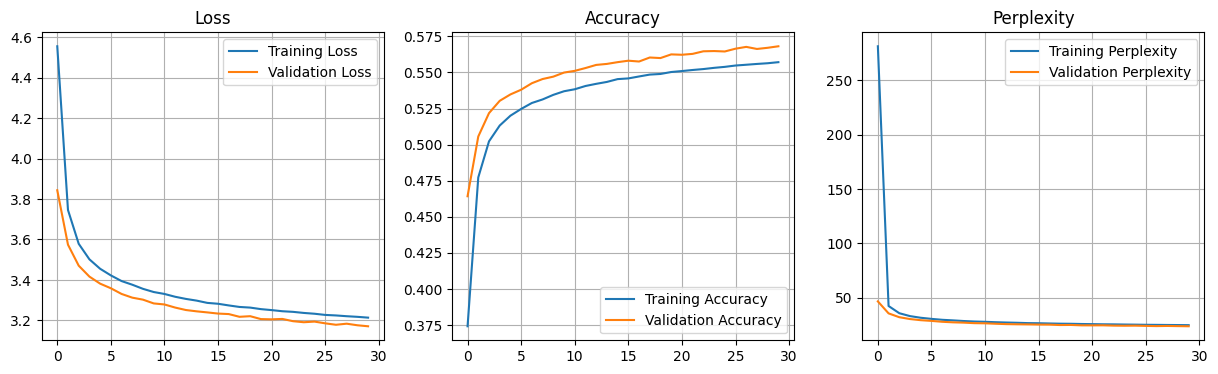

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, key in zip(axes, ["loss", "accuracy", "perplexity"]):
    title = key.capitalize()
    ax.plot(stats["train"][key], label=f"Training {title}")
    ax.plot(stats["validation"][key], label=f"Validation {title}")
    ax.legend()
    ax.set_title(title)
    ax.grid()

## Inference

During inference, the fill in the middle is represented by adding `<FILL_ME>` to the spot where code completion should be applied.

To use the example from above:

```py
for <FILL_ME> in enumerate(names):
```

With that, the model will fill in the gap where the `<FILL_ME>` marker is, with the generated text.

If no `<FILL_ME>` marker is given, it will complete the end of the text. There is no special case for this, but the suffix just ends up being empty.

In [50]:
# Optionally load the model here (so you don't need to train it before)
# You can either specify the directory to the checkpoint, in which case
# it would look for a model.safetensors in that directory,
# or the path directly to the safetensors checkpoint (if you want to rename it)
model = Transformer.from_pretrained("checkpoints/best/").to(device).eval()

In [38]:
def encode_fim(text: str, tokeniser: PreTrainedTokenizer, fill_token: str = "<FILL_ME>") -> torch.Tensor:
    parts = text.split(fill_token)
    assert len(parts) <= 2, "Multiple {fill_token} tokens found, only one is supported."
    prefix = parts[0]
    suffix = parts[1] if len(parts) == 2 else ""

    # The input always starts with a <bos> token (beginning of sequence)
    # Then it's in the order of <prefix>, <suffix>, <middle> (PSM)
    # Same as during training, execpt that the input ends with the <middle> token,
    # so the model generates everything that comes inbetween.
    fim_sequence = [
        tokeniser.bos_token_id,
        tokeniser.prefix_id,
        *tokeniser.encode(prefix, add_special_tokens=False),
        tokeniser.suffix_id,
        *tokeniser.encode(suffix, add_special_tokens=False),
        tokeniser.middle_id,
    ]
    return torch.tensor(fim_sequence)


def generate_sequence_fim(
    text: str | list[str],
    model: Transformer,
    tokeniser: PreTrainedTokenizer,
    device: torch.device,
) -> tuple[str, str] | tuple[list[str], list[str]]:
    inputs = text if isinstance(text, list) else [text]
    inputs = [encode_fim(inp, tokeniser=tokeniser) for inp in inputs]
    collator = PaddingCollator(tokeniser, padding_side="left")
    # Just to reuse the collator, use the same labels and inputs, even though we don't need the labels here.
    batch = collator([dict(input_ids=inp, labels=inp) for inp in inputs])
    out_seq = model.generate(
        batch["input_ids"].to(device),
        pad_token_id=tokeniser.pad_token_id,
        eos_token_id=tokeniser.eos_token_id,
    )
    out_decoded = [decode_fim(seq, tokeniser=tokeniser) for seq in out_seq]
    if isinstance(text, list):
        return out_decoded, out_seq
    else:
        return out_decoded[0], out_seq[0]

In [51]:
out, out_seq = generate_sequence_fim(
    [
        "for <FILL_ME> in enumerate(names):",
        "def multiply_add(a, b):\n out = <FILL_ME>\n    return out",
    ],
    model=model,
    tokeniser=tokeniser,
    device=device,
)

for o in out:
    render_code_block(o)

tensor([True, True], device='cuda:0')


```python
for 1, 2, 3, 4, 5, 6, 7, 8, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  in enumerate(names):
```

```python
def multiply_add(a, b):
 out = 1
    return out

def add_add(a, b):
    return a + b

def add_add(a, b):
    return a + b

def add_add(a, b):
    return a + b

def add_add(a, b):
    return a + b

def add_add(a, b):
    return a + b

def add_add(a, b):
    return a + 
    return out
```

## Attention Visualisation

To visualise the attention, the attention matrix after the softmax needs to be extracted. That would usually require to pass an input through the model up to the attention layer that should be visualised and then calculate the attention from there. Besides being cumbersome, it is also fragile, as the implementation needs to match what the model calculates, but just stop at right after the calculation. The attention matrix is already calculated anyway in the model, so it is much simpler to just store that and continue with the model as usual.

A hook is added that simply stores the matrix whenever a calculation is run. This is non-disruptive, but should still be avoided during the training, as that would add an additional unnecessary overhead.

In [40]:
@dataclass
class AttentionRegistry:
    enabled: bool  = True
    to_cpu: bool = True
    attn_weights: dict[str, torch.Tensor] = field(default_factory=lambda: dict())

    @classmethod
    def with_model(cls, model: nn.Module, *args, **kwargs) -> "AttentionRegistry":
        self = cls(*args, **kwargs)
        self.apply(model)
        return self

    def __getitem__(self, name: str) -> torch.Tensor:
        return self.attn_weights[name]

    def __iter__(self):
        return iter(self.attn_weights.items())
    
    def save(self, name: str, weight: torch.Tensor):
        if not self.enabled:
            return
        weight = weight.detach()
        if self.to_cpu:
            weight = weight.cpu()
        self.attn_weights[name] = weight

    def clear(self):
        self.attn_weights = dict()

    def enable(self):
        self.enabled = True
        
    def disable(self):
        self.enabled = False

    def create_hook(self, name: str) -> "AttentionHook":
        return AttentionHook(name=name, registry=self)

    def apply(self, model: nn.Module):
        for name, module in model.named_modules():
            if isinstance(module, SelfAttention):
                module.register_attention_hook(self.create_hook(name))

@dataclass
class AttentionHook:
    name: str
    registry: AttentionRegistry

    def save(self, weight: torch.Tensor):
        self.registry.save(self.name, weight)

In [41]:
# Normalise attention to have a relative view between the tokens, rather than the absolute values.
def normalise_attention(attn: torch.Tensor, dim=-1, log: bool = False) -> torch.Tensor:
    if log:
        attn = torch.log(attn)
    min, _ = torch.min(attn, dim=dim, keepdim=True)
    max, _ = torch.max(attn, dim=dim, keepdim=True)
    return (attn - min) / (max - min)


def visualise_attention(attn_weight: torch.Tensor, tokens: list[str], token_index: int | None = None, log: bool = False):
    """
    Visualise the attention for a token. If no token index is provided, a random token is selected.
    """
    if token_index is None:
        token_index = torch.randint(attn_weight.size(1), size=(1,)).item()

    # Average all heads to simplify visualisation.
    # And only use the selected token.
    attn_weight = torch.mean(attn_weight, dim=0)
    attn_weight = attn_weight[token_index]
    attn = torch.softmax(attn_weight, dim=-1)
    attn = normalise_attention(attn)
    # Shade of blue, the higher the attention the higher the opacity.
    colours = [f"rgba(50, 120, 255, {prob:.2f})" for prob in attn]
    # The selected token will be marked in RED.
    colours[token_index] = "rgba(255, 136, 136, 0.75)"
    visualise_tokens(tokens, token_colours=colours)

def visualise_attention_for_batch(attn_registry: AttentionRegistry, sequences: list[list[int]], tokeniser: PreTrainedTokenizer):
    for i, seq in enumerate(sequences):
        display(Markdown(f"### Sequence {i}"))
        token_index = torch.randint(len(seq) - 1, size=(1,)).item()
        for name, attn_weight in attn_registry:
            display(Markdown(f"#### {name}"))
            visualise_attention(attn_weight[i], tokeniser.convert_ids_to_tokens(seq[:-1]), token_index=token_index)

@torch.inference_mode()
def generate_and_visualise_attention(text: str | list[str], model: Transformer, tokeniser: PreTrainedTokenizer, device: torch.device):
    assert not isinstance(text, list), "Attention visualisation currently only supports a single input"
    attn_registry = AttentionRegistry.with_model(model)
    model.eval()
    out, out_seq = generate_sequence_fim(text, model=model, tokeniser=tokeniser, device=device)
    if not isinstance(out, list):
        out = [out]
        out_seq = [out_seq]
    visualise_attention_for_batch(attn_registry, out_seq, tokeniser=tokeniser)

For the input sequences, the sequence is generated as usual, and after the last forward pass, the attention matrices of that pass will be stored and visualised for one particular token. One token is selected randomly to visualise its attention, which is marked in <span style="background: rgba(255, 136, 136, 0.75)">red</span>. All other tokens are then coloured in <span style="background: rgba(50, 120, 255, 0.23)">blue</span> with an opacity based on their attention value, e.g. <span style="background: rgba(50, 120, 255, 1.0)">100%</span> attention vs. <span style="background: rgba(50, 120, 255, 0.1)">10%</span> attention.

In [49]:
generate_and_visualise_attention(
    "def multiply_add(a, b):\n out = <FILL_ME>\n    return out",
    model=model,
    tokeniser=tokeniser,
    device=device,
)

tensor([True], device='cuda:0')


### Sequence 0

#### layers.0.attention

#### layers.1.attention

#### layers.2.attention

#### layers.3.attention

## Additional Resources

These are some additional resources, including concepts that have not been covered here, but are very common for Transformer based models, although more related to LLMs.

### Grouped Query Attention (GQA)

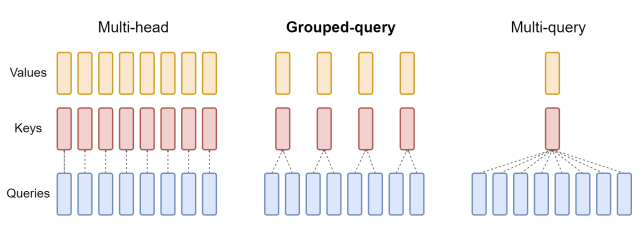

In multi-head attention, there are the same number of heads for query, key and value, whereas grouped query attention, uses fewer heads for key and value (but the full number of query heads), therefore using the same key/value head for a group of query heads (rather than a single one). This is a computational trade-off (espcially useful in conjunction with the KV-caching)

- Paper: [GQA: Training Generalized Multi-Query Transformer Models from Multi-Head Checkpoints](https://arxiv.org/abs/2305.13245)
- Blog post: [Grouped Query Attention (GQA) explained with code](https://medium.com/@maxshapp/grouped-query-attention-gqa-explained-with-code-e56ee2a1df5a)

  
### Key-Value Cache (KV-cache)

In a decoder-only Transformer with causal attention, every time a new token is added to the sequence, the previous tokens won't be affected, hence they should not need to be recalculated. However, the new token still needs the context of the previous tokens. More specifically, the attention calculation for the token at time step $t_{n}$ needs the key and values for all previous tokens ($t_{0}, \dots, t_{n - 1}$), hence these would have to be recalculated. Instead of recalculating them, they can simply be cached. Importantly, since it is causal attention, the previous tokens will never change. Using GQA (mentioned above) significantly reduces the memory needed for the cache.

*This is purely to speed up inference, hence not as prevalent in research.*

- Blog post: [Transformers KV Caching Explained](https://medium.com/@joaolages/kv-caching-explained-276520203249)

### Low-Rank Adaptation (LoRA)

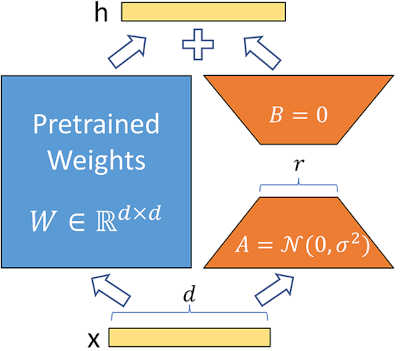

Instead of fully fine-tuning a large pre-trained model, this adds adapters to certain layers, which are used as an additional branch and then merged into the output of the original layer. These adapters are much smaller and therefore require less memory to train as the overall trainable parameter will be a fraction of the full parameters. This is the most commonly used method if you want to fine-tune an LLM for your own data.

- Paper: [LoRA: Low-Rank Adaptation of Large Language Models](https://arxiv.org/abs/2106.09685)
- Blog post: [Parameter-Efficient LLM Finetuning With Low-Rank Adaptation (LoRA)](https://sebastianraschka.com/blog/2023/llm-finetuning-lora.html)

### Quantisation (and QLoRA)

Weight qunatisation is the process of reducing the size of the weight from say 16bit floating point weight (float16/bfloat16) to an 8bit or 4bit integer weight (int8 / int4). There are various strategies to achieve this, but the gist of it is, that lower precision values are used for a range of possible values (bins), where the most naive approach would just be rounding to the nearest integer (which would perform terribly). Quantisation inevitably introduces errors (due to the reduced precision), but reduces the memory requirement drastically. For LLMs, memory is usually the limiting factor, quantisation makes it possible to run and fine-tune much larger models. QLoRA does exactly that, it quantises the whole base model and only keeps the added weights (LoRA adapters) in full precision. The added benefit of combining the quantisation with the LoRA fine-tuning, is that some of the quantisation error can be fixed during the fine-tuning, i.e. the adapters not only adapt the model to your dataset, but also make the model more stable again.

  
- Paper: [QLoRA: Efficient Finetuning of Quantized LLMs](https://arxiv.org/abs/2305.14314)
- Blog post: [QLoRA: Fine-Tuning Large Language Models (LLM’s)](https://medium.com/@dillipprasad60/qlora-explained-a-deep-dive-into-parametric-efficient-fine-tuning-in-large-language-models-llms-c1a4794b1766) (explaining QLoRA and its specific quantisation format)